# Logistic Regression Regularization: Comparison of L2, L1, and Firth's Logistic Regression

You will analyze a simulated clinical-biomarker dataset designed to contain three common problems in biomedical data:

1. limited sample size,
2. correlated predictors,
3. quasi-complete separation.

You will compare:

- unregularized logistic regression,
- L2-regularized logistic regression,
- L1-regularized logistic regression,
- logistic regression with elastic-net regularization,
- Firth's bias-reduced logistic regression.

The emphasis is not only predictive performance, but also coefficient stability, feature selection, and behavior under separation.

## Biological scenario

Suppose you are developing a diagnostic model for detecting a rare inflammatory cardiac condition. The available predictors include demographic variables, standard clinical measurements, blood biomarkers, and imaging-derived variables. The disease is rare, and some imaging markers are highly predictive, producing quasi-complete separation in small samples.

The outcome is binary:

$$
Y_i =
\begin{cases}
1, & \text{if disease is present},\\
0, & \text{if disease is absent}.
\end{cases}
$$

The goal is to compare how different logistic regression approaches behave under these conditions.

## 1. Import libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

np.random.seed(42)

## 2. Generate a synthetic dataset

The dataset has:

- 18 predictors,
- correlated biomarker groups,
- 4 truly disease-associated predictors,
- class imbalance,
- one predictor designed to create quasi-complete separation.

The data are simulated so that the true data-generating process is known. This lets you assess whether each method recovers the true signal or overreacts to artifacts.

In [9]:
def simulate_biomedical_data(n=200, random_state=42):
    rng = np.random.default_rng(random_state)

    # Latent correlation structure
    z1 = rng.normal(size=n)
    z2 = rng.normal(size=n)
    z3 = rng.normal(size=n)

    age = 55 + 12 * rng.normal(size=n)
    bmi = 27 + 4 * rng.normal(size=n)
    sbp = 120 + 15 * rng.normal(size=n)

    # Correlated inflammatory biomarkers
    crp = 0.8 * z1 + 0.4 * rng.normal(size=n)
    il6 = 0.75 * z1 + 0.5 * rng.normal(size=n)
    fibrinogen = 0.65 * z1 + 0.6 * rng.normal(size=n)

    # Correlated imaging variables
    wall_thickness = 0.9 * z2 + 0.4 * rng.normal(size=n)
    edema_score = 0.8 * z2 + 0.5 * rng.normal(size=n)
    strain_abnormality = 0.7 * z2 + 0.6 * rng.normal(size=n)

    # Metabolic variables
    glucose = 0.8 * z3 + 0.6 * rng.normal(size=n)
    insulin = 0.75 * z3 + 0.6 * rng.normal(size=n)
    triglycerides = 0.65 * z3 + 0.7 * rng.normal(size=n)

    # Noise variables
    noise = rng.normal(size=(n, 6))

    X = pd.DataFrame({
        "age": age,
        "bmi": bmi,
        "systolic_bp": sbp,
        "crp": crp,
        "il6": il6,
        "fibrinogen": fibrinogen,
        "wall_thickness": wall_thickness,
        "edema_score": edema_score,
        "strain_abnormality": strain_abnormality,
        "glucose": glucose,
        "insulin": insulin,
        "triglycerides": triglycerides,
        "noise_1": noise[:, 0],
        "noise_2": noise[:, 1],
        "noise_3": noise[:, 2],
        "noise_4": noise[:, 3],
        "noise_5": noise[:, 4],
        "noise_6": noise[:, 5],
    })

    # Standardized design for generating the outcome
    Xs = (X - X.mean()) / X.std(ddof=0)

    # True sparse signal: only five predictors are causal
    eta = (
        -4.0
        + 0.55 * Xs["age"]
        + 0.95 * Xs["crp"]
        + 1.15 * Xs["edema_score"]
        + 0.65 * Xs["glucose"]
    )

    p = 1 / (1 + np.exp(-eta))
    y = rng.binomial(1, p)

    # Quasi-separating imaging flag: almost always positive among diseased cases
    # but occasionally positive among controls.
    sep = np.where(y == 1, rng.binomial(1, 0.88, n), rng.binomial(1, 0.04, n))
    X["late_gadolinium_flag"] = sep

    return X, pd.Series(y, name="disease")

X, y = simulate_biomedical_data()
features = X.columns

X.head()

,age,bmi,systolic_bp,crp,il6,fibrinogen,wall_thickness,edema_score,strain_abnormality,glucose,insulin,triglycerides,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,late_gadolinium_flag
0,61.184925,23.619819,119.110760,-0.285243,0.819803,0.165105,0.287935,0.044084,-0.087419,-0.411331,-0.460978,-0.298477,1.249023,0.687692,1.966127,-1.547833,-0.265360,-0.462521,0
1,48.069533,22.665205,109.060696,-1.026465,-0.941980,0.003624,1.443716,0.793047,0.879122,0.745535,0.994372,0.806768,-1.973683,1.060327,-0.270397,0.739631,2.359772,-0.353244,1
2,70.293367,28.378420,113.782904,0.768452,0.460804,1.246517,-0.040244,0.289473,0.117889,0.825127,0.562695,1.145338,-0.421153,0.118664,0.987247,-0.566713,-0.630962,1.057189,0
3,47.468950,28.517120,129.508656,0.711493,0.459596,-0.241691,0.415685,0.641078,0.813632,-0.733527,-0.172482,-0.943269,0.378639,-2.044728,-1.225392,1.501236,0.401928,-0.762196,1
4,47.360617,32.149324,120.044899,-1.821054,-1.753602,-1.455586,-1.808213,-2.342533,-0.786607,-0.102630,1.098248,-0.260110,-0.170410,0.013237,0.735733,-1.358263,-0.840949,0.272956,0


## 3. Implemention of Firth's logistic regression

Firth's logistic regression maximizes the penalized likelihood

$$
\ell_F(\beta) = \ell(\beta) + \frac{1}{2}\log |I(\beta)|,
$$

where I(beta) is the Fisher information matrix. This correction reduces first-order small-sample bias and gives finite estimates in many cases of complete or quasi-complete separation.

The implementation below uses the adjusted-score Newton algorithm.

In [10]:
class FirthLogisticRegression(BaseEstimator, ClassifierMixin):
    """Small educational implementation of Firth's logistic regression.

    This implementation is intended for teaching and moderate-size datasets.
    It supports binary outcomes and dense numeric predictors.
    """

    def __init__(self, max_iter=100, tol=1e-7, step_halving=25):
        self.max_iter = max_iter
        self.tol = tol
        self.step_halving = step_halving

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -35, 35)
        return 1 / (1 + np.exp(-z))

    def _penalized_loglik(self, X_design, y, beta):
        eta = X_design @ beta
        mu = self._sigmoid(eta)
        eps = 1e-12
        loglik = np.sum(y * np.log(mu + eps) + (1 - y) * np.log(1 - mu + eps))
        w = mu * (1 - mu)
        I = X_design.T @ (w[:, None] * X_design)
        sign, logdet = np.linalg.slogdet(I + 1e-9 * np.eye(I.shape[0]))
        if sign <= 0:
            return -np.inf
        return loglik + 0.5 * logdet

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n, p = X.shape
        X_design = np.column_stack([np.ones(n), X])
        beta = np.zeros(p + 1)

        for iteration in range(self.max_iter):
            eta = X_design @ beta
            mu = self._sigmoid(eta)
            w = np.clip(mu * (1 - mu), 1e-9, None)

            I = X_design.T @ (w[:, None] * X_design)
            I_inv = np.linalg.pinv(I)

            # Diagonal of the hat matrix H = W^(1/2) X I^-1 X' W^(1/2)
            h = np.sum((X_design @ I_inv) * X_design, axis=1) * w

            # Firth adjusted score
            adjusted_score = X_design.T @ (y - mu + h * (0.5 - mu))
            delta = I_inv @ adjusted_score

            old_obj = self._penalized_loglik(X_design, y, beta)
            step = 1.0
            accepted = False
            for _ in range(self.step_halving):
                beta_candidate = beta + step * delta
                new_obj = self._penalized_loglik(X_design, y, beta_candidate)
                if new_obj >= old_obj:
                    beta = beta_candidate
                    accepted = True
                    break
                step *= 0.5

            if not accepted:
                beta = beta + 0.1 * delta

            if np.max(np.abs(step * delta)) < self.tol:
                break

        self.intercept_ = np.array([beta[0]])
        self.coef_ = beta[1:].reshape(1, -1)
        self.n_iter_ = iteration + 1
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        eta = self.intercept_[0] + X @ self.coef_.ravel()
        p = self._sigmoid(eta)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

## 4. Train-test split

* Use train_test_split to define training and testing sets (X_train, X_train, y_train, y_test)
* Use the same split for all methods below
* Define an array of feature names (features)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=7
)
features = X.columns
print('Percentage of cases in train: {}'.format(np.sum(y_train)/len(y_train)))

Percentage of cases in train: 0.046153846153846156


## 5. Model without regularization

* Fit a logistic regression model without applying regularization. Use the following parameters for LogisticRegression:
  * C = np.inf
  * solver="saga"
  * max_iter=10000
  * tol=1e-6
    
* Assess performance by computing the AUC on the test set

* Write a function that takes as inputs:
  * Xtrain
  * y_train
  * the class of the model (LogisticRegression in this case)
  * an arbitrary number of keyword parameters, used to pass keyword parameters of the model
  
  The function should perform a 5-fold random split of the training data and compute the model coefficients for each fold
  
* Write a function that takes as inputs the name of the features and the coefficients of the model computed by the previous function and that create a bar plot of the coefficients with the following properties:
    * Features ordered by the absolute magnitude of their coefficients
    * Display the mean and standard deviation
    * Include a visual indication of the full range (minimum to maximum)



* What happens to the parameters of the model if you increase max_iter and decrease tol ? Why ?
* Do the important parameters for classification correspond to the expected ones ?

In [12]:
model = LogisticRegression(C = np.inf, solver="saga", max_iter=10000)
model.fit(X_train, y_train)
prob = model.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
print("AUC =", roc_auc_score(y_test, prob))

AUC = 0.9356060606060606


In [13]:
def estimate_parameters_range(X_train, y_train, model_class, **kwargs):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    coefs = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        model = model_class(**kwargs)
        model.fit(X_tr, y_tr)
        coef = model.coef_
        coefs.append(model.coef_.ravel())
    coefs = np.array(coefs)
    return coefs

In [14]:
def plot_parameters_range(features, coefs):
    mean_coef = coefs.mean(axis=0)
    min_coef = coefs.min(axis=0)
    max_coef = coefs.max(axis=0)
    std_coef = coefs.std(axis=0)
    order = np.argsort(np.abs(mean_coef))[::-1]
    mean_sorted = mean_coef[order]
    min_sorted = min_coef[order]
    max_sorted = max_coef[order]
    std_sorted = std_coef[order]
    features_sorted = np.array(features)[order]
    x = np.arange(len(features_sorted))
    plt.figure()
    plt.bar(x, mean_sorted)
    plt.errorbar(x, mean_sorted, yerr=std_sorted, fmt='none', capsize=5)
    for i in range(len(features_sorted)):
        plt.plot([i, i], [min_sorted[i], max_sorted[i]])
    plt.xticks(x, features_sorted, rotation=90)
    plt.xlabel("Features (sorted by |coefficient|)")
    plt.ylabel("Coefficient value")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


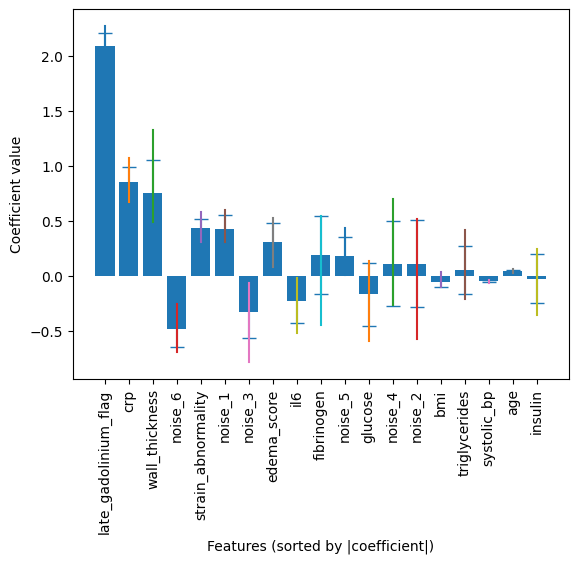

In [15]:
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=np.inf, solver="saga", max_iter=10000, tol=1e-8)
plot_parameters_range(features, coefs)

## 5. Model with L1, L2, and L1+L2 regularization

* Use 5-fold cross-validation to identify the optimal regularization paramter for L2 regularization (test the following values for C np.logspace(-4, 4, 20))
* Estimate the AUC of the best model in the testing set
* Plot the model parameters as before
* Repeat the previous points for L1 regularization, and elastic-net regularization (test the following values for l1_ratio \[0.1, 0.25, 0.5, 0.75, 0.9\])

Best C: 0.03359818286283781
Mean CV AUC: 1.0
Std CV AUC: 0.0
Test AUC: 0.9431818181818181


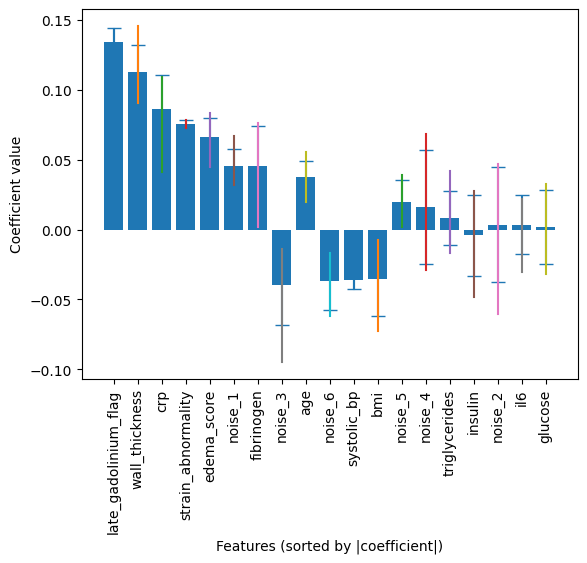

In [16]:
C_grid = np.logspace(-4, 4, 20)
model_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(solver="lbfgs", max_iter=10000))
])
param_grid = {
    "logreg__C": C_grid
}
grid_l2 = GridSearchCV(
    estimator=model_l2,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)
grid_l2.fit(X_train, y_train)
best_idx = grid_l2.best_index_
mean_auc = grid_l2.cv_results_["mean_test_score"][best_idx]
std_auc  = grid_l2.cv_results_["std_test_score"][best_idx]
print("Best C:", grid_l2.best_params_["logreg__C"])
print("Mean CV AUC:", mean_auc)
print("Std CV AUC:", std_auc)
best_model = grid_l2.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print("Test AUC:", test_auc)
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=grid_l2.best_params_["logreg__C"], solver="saga", max_iter=10000)
plot_parameters_range(features, coefs)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Best C: 0.03359818286283781
Mean CV AUC: 1.0
Std CV AUC: 0.0
Test AUC: 0.9431818181818181


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


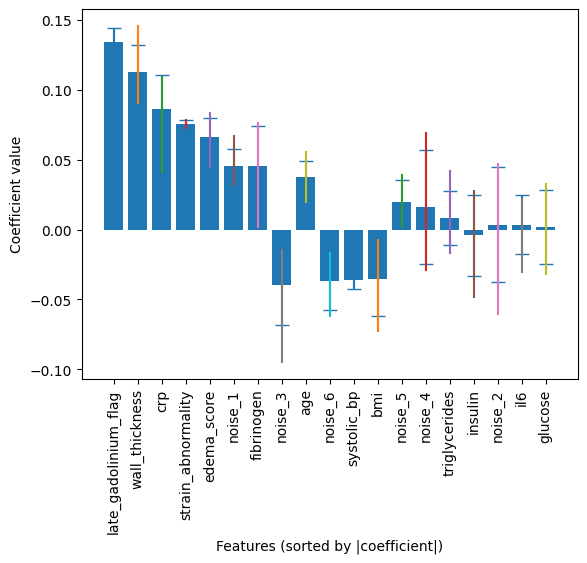

In [17]:
C_grid = np.logspace(-4, 4, 20)
model_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(l1_ratio=1.0, solver="saga", max_iter=10000))
])
param_grid = {
    "logreg__C": C_grid
}
grid_l1 = GridSearchCV(
    estimator=model_l1,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)
grid_l1.fit(X_train, y_train)
best_idx = grid_l1.best_index_
mean_auc = grid_l1.cv_results_["mean_test_score"][best_idx]
std_auc  = grid_l1.cv_results_["std_test_score"][best_idx]
print("Best C:", grid_l1.best_params_["logreg__C"])
print("Mean CV AUC:", mean_auc)
print("Std CV AUC:", std_auc)
best_model = grid_l1.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print("Test AUC:", test_auc)
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=grid_l1.best_params_["logreg__C"], l1_ratio=1.0, solver="saga", max_iter=10000)
plot_parameters_range(features, coefs)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


Best C: 0.03359818286283781
Best l1_ratio: 0.1
Mean CV AUC: 1.0
Std CV AUC: 0.0
Test AUC: 0.9431818181818181


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


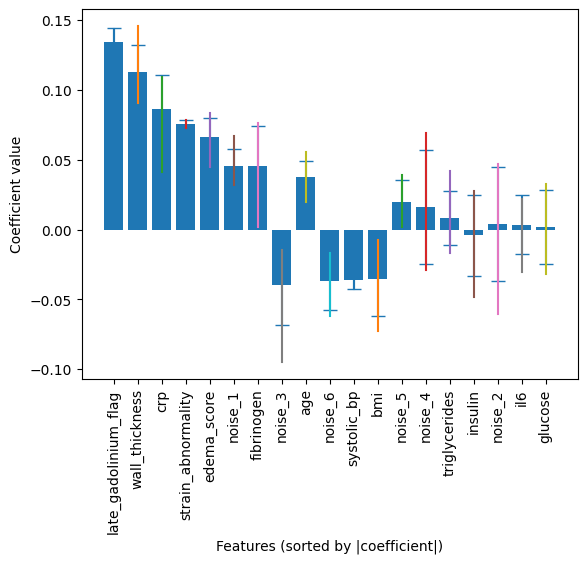

In [18]:
C_grid = np.logspace(-4, 4, 20)
l1_ratio_grid = [0.1, 0.25, 0.5, 0.75, 0.9]
model_en = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="saga",
        max_iter=10000
    ))
])
param_grid = {
    "logreg__C": C_grid,
    "logreg__l1_ratio": l1_ratio_grid
}
grid_en = GridSearchCV(
    estimator=model_en,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)
grid_en.fit(X_train, y_train)

best_idx = grid_en.best_index_
mean_auc = grid_en.cv_results_["mean_test_score"][best_idx]
std_auc  = grid_en.cv_results_["std_test_score"][best_idx]
print("Best C:", grid_en.best_params_["logreg__C"])
print("Best l1_ratio:", grid_en.best_params_["logreg__l1_ratio"])
print("Mean CV AUC:", mean_auc)
print("Std CV AUC:", std_auc)
best_model = grid_en.best_estimator_
y_prob = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob)
print("Test AUC:", test_auc)
coefs = estimate_parameters_range(X_train, y_train, LogisticRegression, C=grid_l1.best_params_["logreg__C"],
                    l1_ratio=grid_en.best_params_["logreg__l1_ratio"], solver="saga", max_iter=10000)
plot_parameters_range(features, coefs)

## 6. Model with Firth's regularization

* Use the class above to train a Firth's logistic regression model
* Plot the model parameters as before

In [19]:
model = FirthLogisticRegression(max_iter=10000, tol=1e-8)
model.fit(X_train, y_train)
prob = model.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
print("AUC =", roc_auc_score(y_test, prob))

AUC = 0.9734848484848485


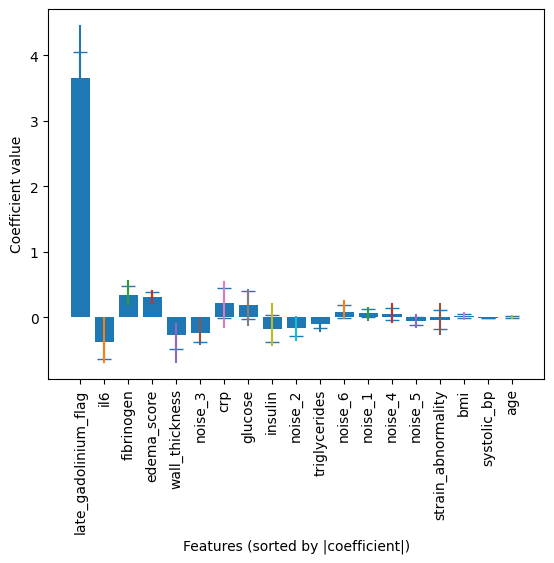

In [20]:
coefs = estimate_parameters_range(X_train, y_train, FirthLogisticRegression, max_iter=100000, tol=1e-10)
plot_parameters_range(features, coefs)